In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from IPython.display import display, Markdown, HTML
file_path = Path(
    "data/Area 51 Helensvale_SurveyResponse_220420261426_919949806.xlsx"
)

df = pd.read_excel(
    file_path,
    sheet_name="GXS"
)

# -----------------------------------
# 1. Prepare dates and rating columns
# -----------------------------------

df["Completed Date"] = pd.to_datetime(
    df["Completed Date"],
    errors="coerce"
)

rating_columns = {
    "Overall": "Overall Rating",
    "Service": "Service Rating",
    "Safety": "Safety Rating",
    "Facilities": "Facilities Rating",
    "Value": "Value Rating"
}

for column in rating_columns.values():
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# -----------------------------------
# 2. Combine written feedback
# -----------------------------------

text_columns = [
    "Comments",
    "Overall Rating Reasons",
    "Service Rating Reasons",
    "Safety Rating Reasons",
    "Facilities Rating Reasons",
    "Value Rating Reasons",
    "Additional Question Comment"
]

available_text_columns = [
    column for column in text_columns
    if column in df.columns
]

df["Feedback Text"] = (
    df[available_text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# -----------------------------------
# 3. Clean Actioned status
# -----------------------------------

actioned = df["Actioned"].fillna(False)

# Handles either True/False values or text values
if actioned.dtype != bool:
    actioned = (
        actioned.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "yes", "1"])
    )

df["Actioned Flag"] = actioned.astype(bool)

# -----------------------------------
# 4. Define complaints
# -----------------------------------

complaint_threshold = 3

rating_column_names = list(rating_columns.values())

df["Lowest Rating"] = (
    df[rating_column_names]
    .min(axis=1)
)

df["Is Complaint"] = (
    df["Feedback Text"].ne("")
    & df[rating_column_names]
        .le(complaint_threshold)
        .any(axis=1)
)

df["Unresolved Complaint"] = (
    df["Is Complaint"]
    & ~df["Actioned Flag"]
)

# -----------------------------------
# 5. Identify recurring themes
# -----------------------------------

theme_keywords = {
    "Food": (
        r"\b(?:food|cafe|coffee|drink|drinks|menu|"
        r"meal|snack|chips)\b"
    ),

    "Socks": (
        r"\b(?:sock|socks|grip socks?)\b"
    ),

    "Toilets": (
        r"\b(?:toilet|toilets|bathroom|bathrooms|"
        r"restroom|washroom)\b"
    ),

    "Cleanliness": (
        r"\b(?:clean|cleanliness|dirty|filthy|hygiene|"
        r"mess|messy|smell|smelly|rubbish|trash|bins?)\b"
    ),

    "Staffing": (
        r"\b(?:staff|staffing|understaffed|employee|"
        r"employees|worker|workers|supervision|supervisor)\b"
    ),

    "Capacity": (
        r"\b(?:crowded|overcrowded|capacity|too busy|packed|"
        r"too many people|too many kids|queue|queues|waiting|"
        r"wait time|long wait)\b"
    ),

    "Value": (
        r"\b(?:value|price|prices|pricing|cost|costs|"
        r"expensive|overpriced|too much|worth|money|fees?)\b"
    )
}

for theme, pattern in theme_keywords.items():
    df[f"Theme - {theme}"] = (
        df["Feedback Text"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
    )

# Combine detected themes into one column
def find_themes(row):
    matches = [
        theme
        for theme in theme_keywords
        if row[f"Theme - {theme}"]
    ]

    return ", ".join(matches) if matches else "Other"

df["Themes"] = df.apply(
    find_themes,
    axis=1
)

print("Dashboard data prepared.")
print(f"Complaints identified: {df['Is Complaint'].sum():,}")
print(
    "Unresolved complaints:",
    f"{df['Unresolved Complaint'].sum():,}"
)

Dashboard data prepared.
Complaints identified: 590
Unresolved complaints: 459


# Area 51 Helensvale Management Dashboard

/var/folders/_t/s9_cqvqj4_n614936xfgdv_00000gn/T/ipykernel_78616/3067121649.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


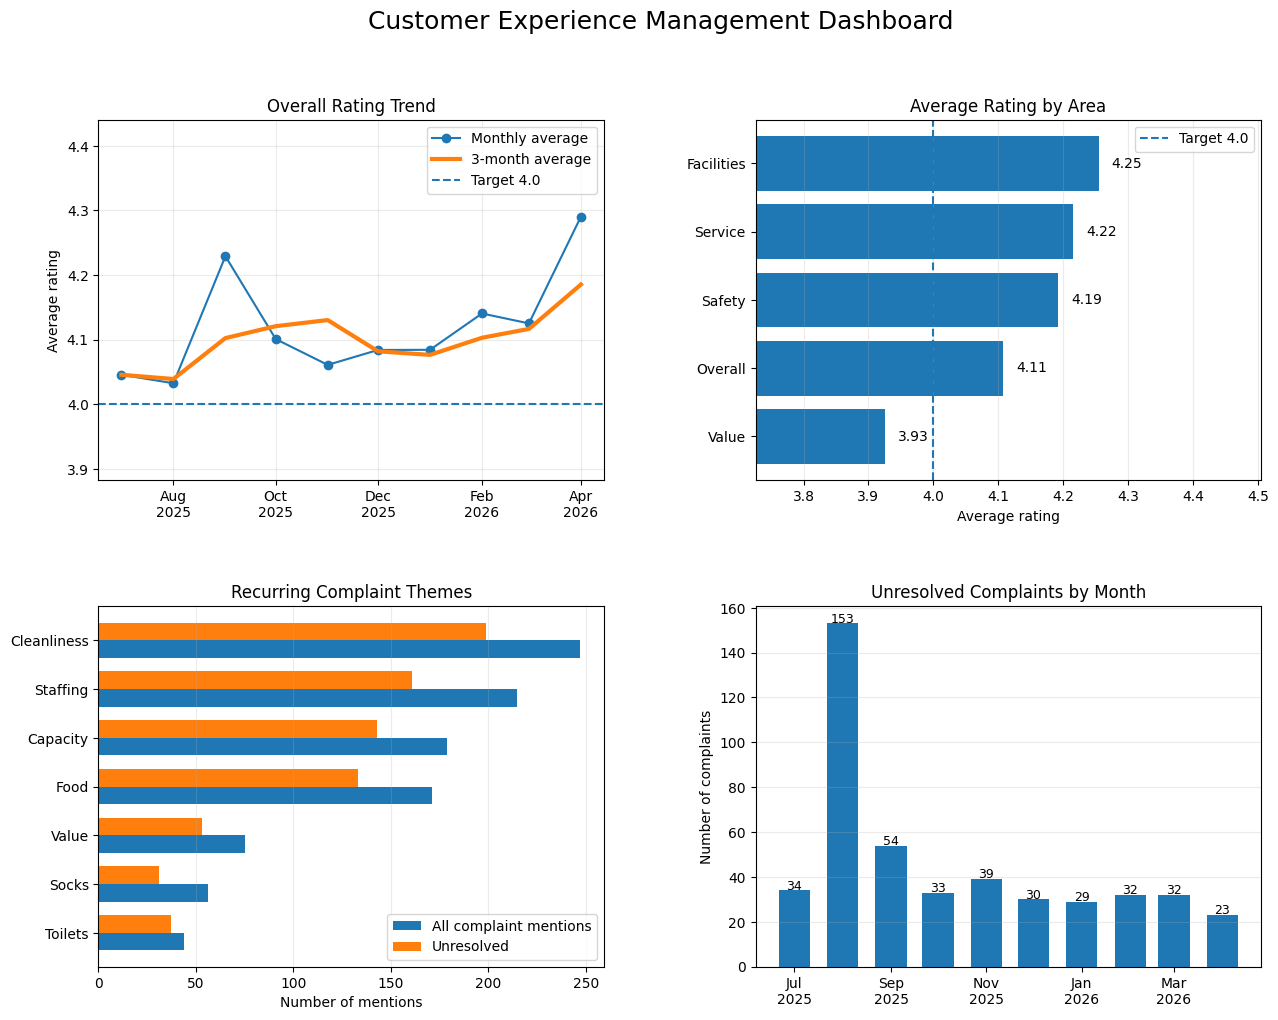

In [3]:
# -----------------------------------
# 1. Calculate KPI values
# -----------------------------------

overall_average = df["Overall Rating"].mean()
overall_responses = df["Overall Rating"].count()

total_complaints = int(
    df["Is Complaint"].sum()
)

unresolved_complaints = int(
    df["Unresolved Complaint"].sum()
)

actioned_complaints = int(
    (
        df["Is Complaint"]
        & df["Actioned Flag"]
    ).sum()
)

if total_complaints > 0:
    complaint_action_rate = (
        actioned_complaints
        / total_complaints
        * 100
    )
else:
    complaint_action_rate = 0

# -----------------------------------
# 2. Display management KPI cards
# -----------------------------------

kpi_cards = f"""
<div style="
    display:flex;
    flex-wrap:wrap;
    gap:12px;
    margin:15px 0 25px 0;
">

    <div style="
        flex:1;
        min-width:180px;
        border:1px solid #dddddd;
        border-radius:8px;
        padding:18px;
    ">
        <div style="font-size:14px;">
            Overall rating
        </div>

        <div style="
            font-size:30px;
            font-weight:bold;
            margin-top:5px;
        ">
            {overall_average:.2f} / 5
        </div>

        <div style="font-size:13px;">
            {overall_responses:,} responses
        </div>
    </div>

    <div style="
        flex:1;
        min-width:180px;
        border:1px solid #dddddd;
        border-radius:8px;
        padding:18px;
    ">
        <div style="font-size:14px;">
            Complaints identified
        </div>

        <div style="
            font-size:30px;
            font-weight:bold;
            margin-top:5px;
        ">
            {total_complaints:,}
        </div>

        <div style="font-size:13px;">
            Rating of 3 or below
        </div>
    </div>

    <div style="
        flex:1;
        min-width:180px;
        border:1px solid #dddddd;
        border-radius:8px;
        padding:18px;
    ">
        <div style="font-size:14px;">
            Unresolved complaints
        </div>

        <div style="
            font-size:30px;
            font-weight:bold;
            margin-top:5px;
        ">
            {unresolved_complaints:,}
        </div>

        <div style="font-size:13px;">
            Not marked as actioned
        </div>
    </div>

    <div style="
        flex:1;
        min-width:180px;
        border:1px solid #dddddd;
        border-radius:8px;
        padding:18px;
    ">
        <div style="font-size:14px;">
            Complaint action rate
        </div>

        <div style="
            font-size:30px;
            font-weight:bold;
            margin-top:5px;
        ">
            {complaint_action_rate:.1f}%
        </div>

        <div style="font-size:13px;">
            {actioned_complaints:,} actioned
        </div>
    </div>

</div>
"""

display(Markdown("# Area 51 Helensvale Management Dashboard"))
display(HTML(kpi_cards))

# -----------------------------------
# 3. Monthly rating trend
# -----------------------------------

monthly_ratings = (
    df
    .set_index("Completed Date")[rating_column_names]
    .resample("MS")
    .mean()
)

monthly_overall = monthly_ratings["Overall Rating"]

three_month_average = (
    monthly_overall
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

# -----------------------------------
# 4. Average ratings by area
# -----------------------------------

rating_summary = pd.Series({
    area: df[column].mean()
    for area, column in rating_columns.items()
}).sort_values()

# -----------------------------------
# 5. Feedback theme summary
# -----------------------------------

theme_summary = pd.DataFrame([
    {
        "Theme": theme,

        "Complaint Mentions": int(
            (
                df["Is Complaint"]
                & df[f"Theme - {theme}"]
            ).sum()
        ),

        "Unresolved": int(
            (
                df["Unresolved Complaint"]
                & df[f"Theme - {theme}"]
            ).sum()
        )
    }
    for theme in theme_keywords
])

theme_summary = theme_summary.sort_values(
    "Complaint Mentions"
)

# -----------------------------------
# 6. Monthly unresolved complaints
# -----------------------------------

first_month = (
    df["Completed Date"]
    .min()
    .to_period("M")
    .to_timestamp()
)

last_month = (
    df["Completed Date"]
    .max()
    .to_period("M")
    .to_timestamp()
)

all_months = pd.date_range(
    first_month,
    last_month,
    freq="MS"
)

monthly_unresolved = (
    df.loc[df["Unresolved Complaint"]]
    .set_index("Completed Date")
    .resample("MS")
    .size()
    .reindex(
        all_months,
        fill_value=0
    )
)

# -----------------------------------
# 7. Create the dashboard
# -----------------------------------

fig = plt.figure(figsize=(15, 11))

grid = fig.add_gridspec(
    2,
    2,
    hspace=0.35,
    wspace=0.30
)

# Chart 1: Overall rating trend
ax1 = fig.add_subplot(grid[0, 0])

ax1.plot(
    monthly_overall.index,
    monthly_overall,
    marker="o",
    label="Monthly average"
)

ax1.plot(
    three_month_average.index,
    three_month_average,
    linewidth=3,
    label="3-month average"
)

ax1.axhline(
    4.0,
    linestyle="--",
    label="Target 4.0"
)

ax1.set_title("Overall Rating Trend")
ax1.set_ylabel("Average rating")
ax1.grid(alpha=0.25)
ax1.legend()

ax1.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax1.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

trend_values = pd.concat([
    monthly_overall,
    three_month_average
]).dropna()

if not trend_values.empty:
    lower_limit = max(
        1,
        trend_values.min() - 0.15
    )

    upper_limit = min(
        5,
        trend_values.max() + 0.15
    )

    ax1.set_ylim(
        lower_limit,
        upper_limit
    )

# Chart 2: Ratings by area
ax2 = fig.add_subplot(grid[0, 1])

rating_bars = ax2.barh(
    rating_summary.index,
    rating_summary.values
)

ax2.axvline(
    4.0,
    linestyle="--",
    label="Target 4.0"
)

for bar, value in zip(
    rating_bars,
    rating_summary.values
):
    ax2.text(
        value + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

minimum_rating = rating_summary.min()
maximum_rating = rating_summary.max()

ax2.set_xlim(
    max(1, min(4.0, minimum_rating) - 0.20),
    min(5, max(4.0, maximum_rating) + 0.25)
)

ax2.set_title("Average Rating by Area")
ax2.set_xlabel("Average rating")
ax2.grid(axis="x", alpha=0.25)
ax2.legend()

# Chart 3: Recurring feedback themes
ax3 = fig.add_subplot(grid[1, 0])

positions = np.arange(
    len(theme_summary)
)

bar_height = 0.36

ax3.barh(
    positions - bar_height / 2,
    theme_summary["Complaint Mentions"],
    height=bar_height,
    label="All complaint mentions"
)

ax3.barh(
    positions + bar_height / 2,
    theme_summary["Unresolved"],
    height=bar_height,
    label="Unresolved"
)

ax3.set_yticks(
    positions,
    theme_summary["Theme"]
)

ax3.set_title("Recurring Complaint Themes")
ax3.set_xlabel("Number of mentions")
ax3.grid(axis="x", alpha=0.25)
ax3.legend()

# Chart 4: Unresolved complaints by month
ax4 = fig.add_subplot(grid[1, 1])

complaint_bars = ax4.bar(
    monthly_unresolved.index,
    monthly_unresolved.values,
    width=20
)

for bar, value in zip(
    complaint_bars,
    monthly_unresolved.values
):
    if value > 0:
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.5,
            f"{int(value)}",
            ha="center",
            fontsize=9
        )

ax4.set_title("Unresolved Complaints by Month")
ax4.set_ylabel("Number of complaints")
ax4.grid(axis="y", alpha=0.25)

ax4.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

ax4.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

fig.suptitle(
    "Customer Experience Management Dashboard",
    fontsize=18,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

In [4]:
# Use the latest survey date as the dashboard reporting date
reporting_date = (
    df["Completed Date"]
    .max()
    .normalize()
)

unresolved_table = df.loc[
    df["Unresolved Complaint"],
    [
        "Completed Date",
        "Booking ID",
        "Lowest Rating",
        "Themes",
        "Feedback Text",
        "Internal Note"
    ]
].copy()

unresolved_table["Days Open"] = (
    reporting_date
    - unresolved_table["Completed Date"]
).dt.days

# Shorten long text for easier notebook viewing
unresolved_table["Feedback"] = (
    unresolved_table["Feedback Text"]
    .str.slice(0, 220)
)

unresolved_table["Internal Note"] = (
    unresolved_table["Internal Note"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.slice(0, 150)
)

unresolved_table = (
    unresolved_table[
        [
            "Completed Date",
            "Booking ID",
            "Lowest Rating",
            "Themes",
            "Days Open",
            "Feedback",
            "Internal Note"
        ]
    ]
    .sort_values(
        ["Days Open", "Lowest Rating"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(Markdown(
    f"""
## Unresolved Complaint Register

There are **{len(unresolved_table):,} unresolved complaints**.

The table below shows the **20 oldest unresolved complaints** as of  
**{reporting_date.strftime('%d %B %Y')}**.
"""
))

display(
    unresolved_table
    .head(20)
    .style
    .hide(axis="index")
    .format({
        "Completed Date": lambda value: (
            value.strftime("%d %b %Y")
            if pd.notna(value)
            else ""
        ),
        "Lowest Rating": "{:.0f}",
        "Days Open": "{:,}"
    })
    .set_properties(
        subset=["Feedback", "Internal Note"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "max-width": "350px"
        }
    )
)


## Unresolved Complaint Register

There are **459 unresolved complaints**.

The table below shows the **20 oldest unresolved complaints** as of  
**22 April 2026**.


Completed Date,Booking ID,Lowest Rating,Themes,Days Open,Feedback,Internal Note
26 Jul 2025,93340179.000000,2,Capacity,270,Knowledge Capacity,
26 Jul 2025,93345730.000000,2,"Food, Capacity, Value",270,7.50 for chips and we got about 15chips ridiculously expensive. Not enough seating Efficient Capacity,
26 Jul 2025,93425886.000000,2,Other,270,"The kids had the best time! I would just recommend maybe kids safety gate at the front entry, i was with 2, 3 year olds on the playground when i lost sight of 1, i was looking everywhere on the playground not realising h",
26 Jul 2025,93334250.000000,3,Other,270,"Professionalism, Helpfulness, Patience, Friendliness Maintenance, Temperature, FacilityAge",
26 Jul 2025,93336567.000000,3,"Food, Cleanliness, Staffing, Capacity",270,"Could have a team worker watching over the table areas as our child's drink was stolen by another child. However we let the kitchen staff know and they were incredibly understanding, polite and friendly and replaced our",
26 Jul 2025,93343085.000000,3,"Cleanliness, Value",270,"Pricing is a bit high for what the kids get in the end. I was expecting more areas for them to run around in Cleanliness, Hygiene FacilityAge",
26 Jul 2025,93360200.000000,3,Toilets,270,"Needs toilets upstairs and change table for easier access for parents with babies or toddlers. Consideration, Friendliness Been to another site before",
26 Jul 2025,93408962.000000,3,Cleanliness,270,"Cleanliness, Equipment",
26 Jul 2025,93409538.000000,3,Other,270,Would do with same wall benches for those who can’t obtain a table with seating Equipment Variety Was not aware when booking tickets it was aimed at 12 and under so that’s a shame,
27 Jul 2025,93354247.000000,1,"Food, Cleanliness, Staffing, Capacity",269,"Friendliness Hygiene, Cleanliness, Supervision Maintenance, Food FamilyFriendly, Capacity",
